# EDA — Picoclimate track-based dataset
This notebook performs an exploratory data analysis (EDA) of the track-based CSV at `data/picoclimate_test/tracks_measurements.csv`.
Goals: load a sample, inspect schema, check missingness, plot track-length distribution, and sample time-series for a representative track.

In [37]:
# Imports
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [38]:
# Paths and quick checks
# DATA_PATH = Path('data/picoclimate_test/tracks_measurements.csv')
DATA_PATH = Path(r"D:\repositories\personal\xai-spatio-temporal\data\picoclimate_test\tracks_measurements.csv")
print('Data path:', DATA_PATH)
print('Exists:', DATA_PATH.exists())
if DATA_PATH.exists():
    print('Size (MB):', DATA_PATH.stat().st_size / (1024**2))

Data path: D:\repositories\personal\xai-spatio-temporal\data\picoclimate_test\tracks_measurements.csv
Exists: True
Size (MB): 25.273386001586914


In [39]:
# Load a small sample first to inspect columns and dtypes
if DATA_PATH.exists():
    sample = pd.read_csv(DATA_PATH, nrows=1000, low_memory=False)
    display(sample.head())
    print('\nColumns:', list(sample.columns))
else:
    print('File not found — please ensure the CSV exists locally at', DATA_PATH)

,track_id,city,date,time_slot,slot_index,loc_id,loc_index,timestamp,true_regime,air_temp_c,rel_humidity_pct,wind_speed_ms,wind_dir_deg,pressure_hpa,precipitation_mm,solar_wm2,longwave_wm2,surface_temp_c,soil_moisture_pct,ndvi,pm25_ugm3,pm10_ugm3,co2_ppm,no2_ppb,o3_ppb,noise_db,traffic_index,pedestrian_index,sky_view_factor,impervious_fraction,water_proximity,heat_index_c
0,nan_track_000,Nantes,2026-05-02,noon,1,nan_track_000_loc_000,0,2026-05-02T12:00:00+00:00,dry_spell,13.183428,62.206470,3.872512,113.424937,1010.930654,0.0,123.213684,300.530106,16.624277,28.777424,0.374647,7.763550,22.474205,396.667112,21.460434,52.815136,48.902536,0.311897,0.202295,0.504989,0.554530,0.196857,14.404075
1,nan_track_000,Nantes,2026-05-02,noon,1,nan_track_000_loc_001,1,2026-05-02T12:10:00+00:00,dry_spell,16.147433,61.717926,4.904566,140.383858,1010.189329,0.0,142.976310,315.461445,13.755972,32.591330,0.340941,6.293076,21.897954,384.000310,14.314304,49.748408,49.351010,0.406288,0.073647,0.376633,0.530562,0.175490,17.319226
2,nan_track_000,Nantes,2026-05-02,noon,1,nan_track_000_loc_002,2,2026-05-02T12:20:00+00:00,dry_spell,14.002191,66.691213,3.588351,67.501557,1007.437677,0.0,192.185819,296.034393,14.771046,29.843397,0.335404,13.656633,22.845938,391.096997,19.708189,53.501103,45.003305,0.324462,0.094696,0.485197,0.530214,0.083219,15.671313
3,nan_track_000,Nantes,2026-05-02,noon,1,nan_track_000_loc_003,3,2026-05-02T12:30:00+00:00,dry_spell,16.357433,66.704458,5.470994,109.671397,1006.000065,0.0,126.721453,267.409275,17.709100,31.261531,0.364278,13.810507,21.560026,415.759597,10.698806,34.389410,43.349257,0.166813,0.208074,0.347858,0.552415,0.185028,18.027879
4,nan_track_000,Nantes,2026-05-02,noon,1,nan_track_000_loc_004,4,2026-05-02T12:40:00+00:00,dry_spell,14.147810,60.866629,1.000805,98.270540,1008.530040,0.0,88.645302,288.805922,17.953879,28.118229,0.371518,15.912965,17.681267,396.447340,34.700834,47.501256,47.412261,0.210641,0.225984,0.525087,0.515828,0.000000,15.234473



Columns: ['track_id', 'city', 'date', 'time_slot', 'slot_index', 'loc_id', 'loc_index', 'timestamp', 'true_regime', 'air_temp_c', 'rel_humidity_pct', 'wind_speed_ms', 'wind_dir_deg', 'pressure_hpa', 'precipitation_mm', 'solar_wm2', 'longwave_wm2', 'surface_temp_c', 'soil_moisture_pct', 'ndvi', 'pm25_ugm3', 'pm10_ugm3', 'co2_ppm', 'no2_ppb', 'o3_ppb', 'noise_db', 'traffic_index', 'pedestrian_index', 'sky_view_factor', 'impervious_fraction', 'water_proximity', 'heat_index_c']


In [40]:
# Load full file (careful: may be large). Use chunks if needed.
def load_df(path, nrows=None):
    if nrows is not None:
        return pd.read_csv(path, nrows=nrows, low_memory=False)
    return pd.read_csv(path, low_memory=False)

df = None
if DATA_PATH.exists():
    try:
        df = load_df(DATA_PATH)
    except MemoryError:
        print('MemoryError: try loading a smaller sample with nrows or use chunksize')

if df is not None:
    print('Loaded df shape:', df.shape)
    display(df.head())

Loaded df shape: (53054, 32)


,track_id,city,date,time_slot,slot_index,loc_id,loc_index,timestamp,true_regime,air_temp_c,rel_humidity_pct,wind_speed_ms,wind_dir_deg,pressure_hpa,precipitation_mm,solar_wm2,longwave_wm2,surface_temp_c,soil_moisture_pct,ndvi,pm25_ugm3,pm10_ugm3,co2_ppm,no2_ppb,o3_ppb,noise_db,traffic_index,pedestrian_index,sky_view_factor,impervious_fraction,water_proximity,heat_index_c
0,nan_track_000,Nantes,2026-05-02,noon,1,nan_track_000_loc_000,0,2026-05-02T12:00:00+00:00,dry_spell,13.183428,62.206470,3.872512,113.424937,1010.930654,0.0,123.213684,300.530106,16.624277,28.777424,0.374647,7.763550,22.474205,396.667112,21.460434,52.815136,48.902536,0.311897,0.202295,0.504989,0.554530,0.196857,14.404075
1,nan_track_000,Nantes,2026-05-02,noon,1,nan_track_000_loc_001,1,2026-05-02T12:10:00+00:00,dry_spell,16.147433,61.717926,4.904566,140.383858,1010.189329,0.0,142.976310,315.461445,13.755972,32.591330,0.340941,6.293076,21.897954,384.000310,14.314304,49.748408,49.351010,0.406288,0.073647,0.376633,0.530562,0.175490,17.319226
2,nan_track_000,Nantes,2026-05-02,noon,1,nan_track_000_loc_002,2,2026-05-02T12:20:00+00:00,dry_spell,14.002191,66.691213,3.588351,67.501557,1007.437677,0.0,192.185819,296.034393,14.771046,29.843397,0.335404,13.656633,22.845938,391.096997,19.708189,53.501103,45.003305,0.324462,0.094696,0.485197,0.530214,0.083219,15.671313
3,nan_track_000,Nantes,2026-05-02,noon,1,nan_track_000_loc_003,3,2026-05-02T12:30:00+00:00,dry_spell,16.357433,66.704458,5.470994,109.671397,1006.000065,0.0,126.721453,267.409275,17.709100,31.261531,0.364278,13.810507,21.560026,415.759597,10.698806,34.389410,43.349257,0.166813,0.208074,0.347858,0.552415,0.185028,18.027879
4,nan_track_000,Nantes,2026-05-02,noon,1,nan_track_000_loc_004,4,2026-05-02T12:40:00+00:00,dry_spell,14.147810,60.866629,1.000805,98.270540,1008.530040,0.0,88.645302,288.805922,17.953879,28.118229,0.371518,15.912965,17.681267,396.447340,34.700834,47.501256,47.412261,0.210641,0.225984,0.525087,0.515828,0.000000,15.234473


In [41]:
df[(df['track_id'] == 'nan_track_000') & (df['date'] == '2026-05-02')]

,track_id,city,date,time_slot,slot_index,loc_id,loc_index,timestamp,true_regime,air_temp_c,rel_humidity_pct,wind_speed_ms,wind_dir_deg,pressure_hpa,precipitation_mm,solar_wm2,longwave_wm2,surface_temp_c,soil_moisture_pct,ndvi,pm25_ugm3,pm10_ugm3,co2_ppm,no2_ppb,o3_ppb,noise_db,traffic_index,pedestrian_index,sky_view_factor,impervious_fraction,water_proximity,heat_index_c
0,nan_track_000,Nantes,2026-05-02,noon,1,nan_track_000_loc_000,0,2026-05-02T12:00:00+00:00,dry_spell,13.183428,62.206470,3.872512,113.424937,1010.930654,0.000000,123.213684,300.530106,16.624277,28.777424,0.374647,7.763550,22.474205,396.667112,21.460434,52.815136,48.902536,0.311897,0.202295,0.504989,0.554530,0.196857,14.404075
1,nan_track_000,Nantes,2026-05-02,noon,1,nan_track_000_loc_001,1,2026-05-02T12:10:00+00:00,dry_spell,16.147433,61.717926,4.904566,140.383858,1010.189329,0.000000,142.976310,315.461445,13.755972,32.591330,0.340941,6.293076,21.897954,384.000310,14.314304,49.748408,49.351010,0.406288,0.073647,0.376633,0.530562,0.175490,17.319226
2,nan_track_000,Nantes,2026-05-02,noon,1,nan_track_000_loc_002,2,2026-05-02T12:20:00+00:00,dry_spell,14.002191,66.691213,3.588351,67.501557,1007.437677,0.000000,192.185819,296.034393,14.771046,29.843397,0.335404,13.656633,22.845938,391.096997,19.708189,53.501103,45.003305,0.324462,0.094696,0.485197,0.530214,0.083219,15.671313
3,nan_track_000,Nantes,2026-05-02,noon,1,nan_track_000_loc_003,3,2026-05-02T12:30:00+00:00,dry_spell,16.357433,66.704458,5.470994,109.671397,1006.000065,0.000000,126.721453,267.409275,17.709100,31.261531,0.364278,13.810507,21.560026,415.759597,10.698806,34.389410,43.349257,0.166813,0.208074,0.347858,0.552415,0.185028,18.027879
4,nan_track_000,Nantes,2026-05-02,noon,1,nan_track_000_loc_004,4,2026-05-02T12:40:00+00:00,dry_spell,14.147810,60.866629,1.000805,98.270540,1008.530040,0.000000,88.645302,288.805922,17.953879,28.118229,0.371518,15.912965,17.681267,396.447340,34.700834,47.501256,47.412261,0.210641,0.225984,0.525087,0.515828,0.000000,15.234473
5,nan_track_000,Nantes,2026-05-02,noon,1,nan_track_000_loc_005,5,2026-05-02T12:50:00+00:00,dry_spell,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,nan_track_000,Nantes,2026-05-02,noon,1,nan_track_000_loc_006,6,2026-05-02T13:00:00+00:00,dry_spell,14.443560,67.690717,2.837670,130.227570,1008.190833,0.000000,56.192173,283.698806,15.563357,25.775488,0.374462,13.196601,18.902806,383.361187,18.116660,40.345680,44.638158,0.286209,0.153543,0.411920,0.483672,0.192371,16.212632
7,nan_track_000,Nantes,2026-05-02,noon,1,nan_track_000_loc_007,7,2026-05-02T13:10:00+00:00,dry_spell,13.626318,63.762634,2.114390,102.663753,1006.751152,0.000000,1.137493,244.513932,16.019265,30.194732,0.350550,8.271104,20.522428,375.708375,11.234455,45.285930,43.405620,0.186905,0.179570,0.379725,0.413431,0.000000,15.002582
8,nan_track_000,Nantes,2026-05-02,noon,1,nan_track_000_loc_008,8,2026-05-02T13:20:00+00:00,dry_spell,13.888747,65.694729,1.723738,142.132669,1005.390415,0.000000,42.493682,282.091452,15.952275,33.305974,0.348705,9.709761,23.944981,387.328549,14.160022,47.681375,49.187456,0.272876,0.000000,0.397145,0.411998,0.032749,15.458219
9,nan_track_000,Nantes,2026-05-02,noon,1,nan_track_000_loc_009,9,2026-05-02T13:30:00+00:00,dry_spell,14.081740,58.365954,3.498065,117.823731,1005.709854,0.000000,49.399972,272.960777,16.632071,31.358438,0.414292,5.893109,23.744011,392.778291,15.498149,52.142501,47.588452,0.261105,0.074235,0.398885,0.483363,0.132116,14.918335


In [42]:
# Basic info and descriptive stats
if df is not None:
    display(df.info())
    display(df.describe(include='all'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53054 entries, 0 to 53053
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   track_id             53054 non-null  object 
 1   city                 53054 non-null  object 
 2   date                 53054 non-null  object 
 3   time_slot            53054 non-null  object 
 4   slot_index           53054 non-null  int64  
 5   loc_id               53054 non-null  object 
 6   loc_index            53054 non-null  int64  
 7   timestamp            53054 non-null  object 
 8   true_regime          53054 non-null  object 
 9   air_temp_c           50318 non-null  float64
 10  rel_humidity_pct     50318 non-null  float64
 11  wind_speed_ms        50318 non-null  float64
 12  wind_dir_deg         50318 non-null  float64
 13  pressure_hpa         50318 non-null  float64
 14  precipitation_mm     50318 non-null  float64
 15  solar_wm2            50318 non-null 

None

,track_id,city,date,time_slot,slot_index,loc_id,loc_index,timestamp,true_regime,air_temp_c,rel_humidity_pct,wind_speed_ms,wind_dir_deg,pressure_hpa,precipitation_mm,solar_wm2,longwave_wm2,surface_temp_c,soil_moisture_pct,ndvi,pm25_ugm3,pm10_ugm3,co2_ppm,no2_ppb,o3_ppb,noise_db,traffic_index,pedestrian_index,sky_view_factor,impervious_fraction,water_proximity,heat_index_c
count,53054,53054,53054,53054,53054.000000,53054,53054.000000,53054,53054,50318.000000,50318.000000,50318.000000,50318.000000,50318.000000,50318.000000,50318.000000,50318.000000,50318.000000,50318.000000,50318.000000,50318.000000,50318.000000,50318.000000,50318.000000,50318.000000,50318.000000,50318.000000,50318.000000,50318.000000,50318.000000,50318.000000,50318.000000
unique,16,2,21,4,NaN,2400,NaN,3127,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,nan_track_008,Nantes,2026-05-18,noon,NaN,nan_track_008_loc_011,NaN,2026-05-18T22:50:00+00:00,dry_spell,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,6611,36242,5505,14237,NaN,38,NaN,44,28311,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,1.502243,NaN,76.988540,NaN,NaN,19.951608,67.202359,5.919750,179.925881,1012.002406,0.237171,296.942447,349.809219,21.991118,37.131204,0.513926,14.984075,24.987665,419.960700,24.981710,59.956395,54.979453,0.400191,0.301298,0.499775,0.600038,0.301430,21.671844
std,NaN,NaN,NaN,NaN,1.101516,NaN,47.896586,NaN,NaN,4.087613,10.298536,2.388681,66.748827,4.063312,0.568938,152.153872,60.109323,4.496724,9.156023,0.154374,4.633971,6.919809,23.520526,8.657163,12.221869,6.383703,0.172965,0.170402,0.086271,0.086958,0.170904,4.606639
min,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,NaN,NaN,9.103455,25.386151,0.000000,4.233138,998.688534,0.000000,0.000000,200.000000,9.569811,8.088446,0.108872,0.000000,3.114454,354.269692,0.000000,18.852088,36.983583,0.000000,0.000000,0.185513,0.329695,0.000000,9.929863
25%,NaN,NaN,NaN,NaN,1.000000,NaN,37.000000,NaN,NaN,16.627075,60.138303,3.952408,119.294911,1008.711910,0.000000,164.372424,296.545949,17.982972,30.538731,0.383241,11.570313,19.621291,400.170312,18.323460,50.060249,49.718908,0.266008,0.165734,0.433246,0.532704,0.165908,17.697734
50%,NaN,NaN,NaN,NaN,1.000000,NaN,74.000000,NaN,NaN,19.958820,67.196759,5.916227,180.039350,1011.988998,0.000000,296.970291,349.908216,21.979953,37.053789,0.513381,14.995350,25.014759,419.887830,24.994423,59.906034,55.015194,0.400166,0.300063,0.500402,0.599185,0.299049,21.662889
75%,NaN,NaN,NaN,NaN,2.000000,NaN,112.000000,NaN,NaN,23.199327,74.933099,7.869121,240.168837,1015.302633,0.000000,429.393644,403.249436,25.976473,44.150575,0.645758,18.402279,30.279032,439.728046,31.663093,69.844562,60.233899,0.532421,0.432413,0.566181,0.666902,0.433481,25.633026


In [43]:
# Missing values summary
if df is not None:
    mv = df.isnull().sum().sort_values(ascending=False)
    display(mv[mv>0].head(50))

wind_dir_deg           2736
solar_wm2              2736
pressure_hpa           2736
precipitation_mm       2736
rel_humidity_pct       2736
wind_speed_ms          2736
air_temp_c             2736
o3_ppb                 2736
no2_ppb                2736
co2_ppm                2736
pm10_ugm3              2736
pm25_ugm3              2736
ndvi                   2736
soil_moisture_pct      2736
surface_temp_c         2736
longwave_wm2           2736
sky_view_factor        2736
noise_db               2736
traffic_index          2736
pedestrian_index       2736
water_proximity        2736
impervious_fraction    2736
heat_index_c           2736
dtype: int64

In [44]:
# Identify ID and time columns heuristically
id_candidates = ['loc_id','track_id','id','location_id','sensor_id']
time_candidates = ['timestamp','time','datetime','date','ts']
id_col = None
time_col = None
if df is not None:
    cols = set(df.columns.str.lower())
    for c in id_candidates:
        if c in cols:
            # find actual column name with that lowercase
            id_col = [x for x in df.columns if x.lower()==c][0]
            break
    for c in time_candidates:
        if c in cols:
            time_col = [x for x in df.columns if x.lower()==c][0]
            break
    print('Detected id_col ->', id_col, 'time_col ->', time_col)

Detected id_col -> loc_id time_col -> timestamp


count    2400.000000
mean       22.105833
std         7.089116
min         5.000000
25%        19.000000
50%        21.000000
75%        27.000000
max        38.000000
Name: count, dtype: float64

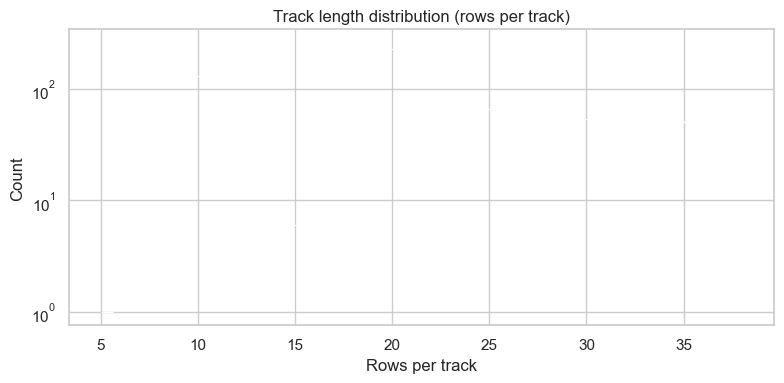

In [45]:
# Track-length distribution (number of rows per id)
if df is not None and id_col is not None:
    track_counts = df.groupby(id_col).size().rename('count')
    display(track_counts.describe())
    plt.figure(figsize=(8,4))
    sns.histplot(x=track_counts.to_numpy(), bins=50, log_scale=(False, True))
    plt.title('Track length distribution (rows per track)')
    plt.xlabel('Rows per track')
    plt.tight_layout()
else:
    print('Cannot compute track lengths: id_col not detected or df missing')

Numeric columns count: 25
Top numeric columns: ['slot_index', 'loc_index', 'air_temp_c', 'rel_humidity_pct', 'wind_speed_ms', 'wind_dir_deg']


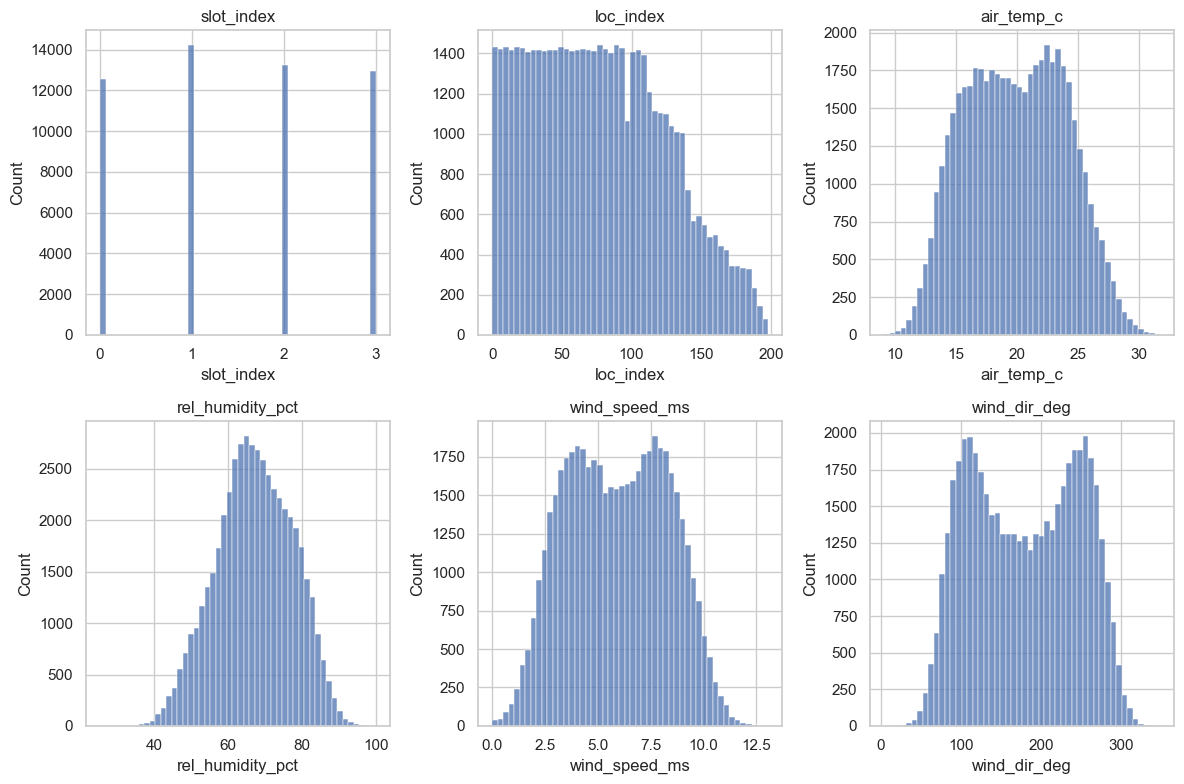

In [46]:
# Numeric columns overview and distributions for top numeric features
if df is not None:
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    print('Numeric columns count:', len(num_cols))
    top_num = num_cols[:6]
    print('Top numeric columns:', top_num)
    if top_num:
        plt.figure(figsize=(12,8))
        for i, c in enumerate(top_num, 1):
            plt.subplot(2,3,i)
            sns.histplot(df[c].dropna(), bins=50)
            plt.title(c)
        plt.tight_layout()

Top id (most rows): nan_track_008_loc_154


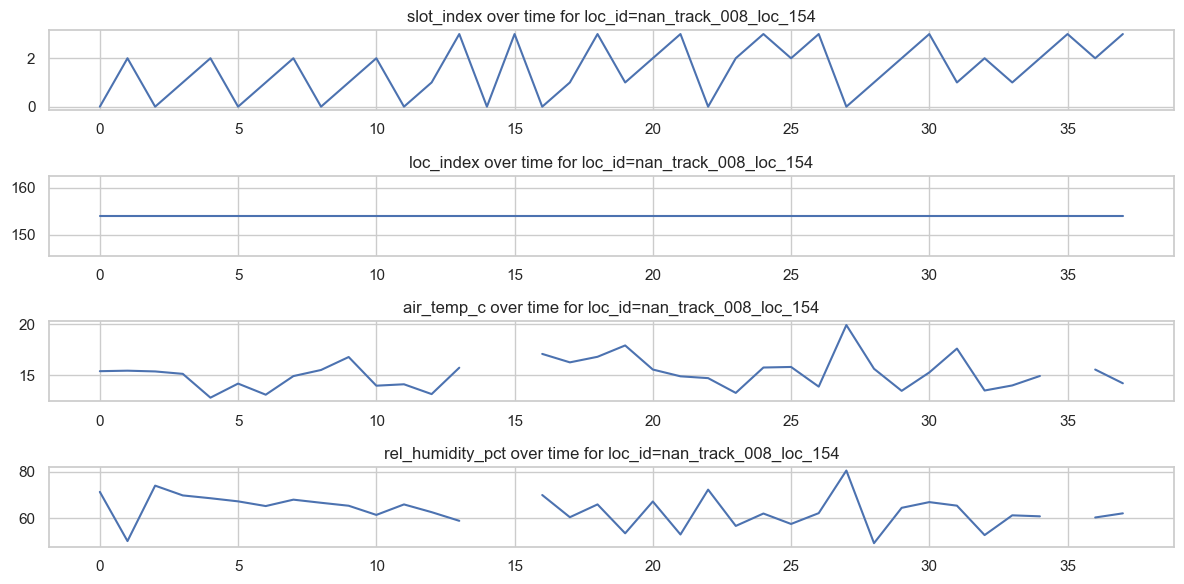

In [47]:
# Sample time-series for a representative track
if df is not None and id_col is not None:
    top_id = track_counts.sort_values(ascending=False).index[0]
    print('Top id (most rows):', top_id)
    track_df = df[df[id_col]==top_id].copy()
    if time_col is not None:
        track_df[time_col] = pd.to_datetime(track_df[time_col], errors='coerce')
        track_df = track_df.sort_values(time_col)
    numeric = track_df.select_dtypes(include=[np.number]).columns.tolist()[:4]
    plt.figure(figsize=(12,6))
    for i,c in enumerate(numeric,1):
        plt.subplot(len(numeric),1,i)
        plt.plot(track_df[c].values)
        plt.title(f'{c} over time for {id_col}={top_id}')
    plt.tight_layout()
else:
    print('Cannot plot time-series: missing df or id_col')

In [48]:
# Save a compact summary to outputs/
OUT_DIR = Path('outputs/eda_picoclimate')
OUT_DIR.mkdir(parents=True, exist_ok=True)
if df is not None:
    summary = {
        'rows': int(df.shape[0]),
        'cols': int(df.shape[1]),
        'unique_ids': int(df[id_col].nunique()) if id_col is not None else None,
    }
    pd.DataFrame([summary]).to_csv(OUT_DIR / 'summary.csv', index=False)
    print('Wrote', OUT_DIR / 'summary.csv')

Wrote outputs\eda_picoclimate\summary.csv


## Next steps
- Consider loading with `chunksize` if memory is constrained.
- Add specialized per-variable plots and seasonal/time-of-day aggregations.
- Export cleaned subset for modeling or shapelet extraction.